In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier

In [ ]:
df=pd.read_csv("fake_and_real_news_dataset.csv")

In [ ]:

# Show column names to find the label column (usually it's 'label' or 'category')
print(df.columns)

# Now count the FAKE and REAL in the first 100 rows
label_counts = df['label'].iloc[:4598].value_counts()

# Print the counts
print("Label counts ")
print(label_counts)

Index(['idd', 'title', 'text', 'label'], dtype='object')
Label counts 
label
REAL    2297
FAKE    2297
Name: count, dtype: int64


In [ ]:
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
# View the first few rows
print(df.head())

# Add a binary label: 1 for fake, 0 for real
df['label'] = df['label'].map({'FAKE': 1, 'REAL': 0})

# Drop rows with missing text
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip().astype(bool)]

# Reset index
df = df.reset_index(drop=True)


          idd                                              title  \
0  KxXYande(Q  N.H. Union Leader picks Johnson over Trump. Bu...   
1  ^C+k6AXAHx             Cruz, Kasich join forces to stop Trump   
2  D7yD7yBjLt  Battle over Scalia’s replacement already spill...   
3  GGri@!f%Do  Chart Of The Day: Russia Must Want War—Look Ho...   
4  YG*##GlEwm  Ryan so far proves he can 'make the sausage,' ...   

                                                text label  
0  In spite of its century-long record of endorsi...  REAL  
1  (CNN) Ted Cruz and John Kasich are joining for...  REAL  
2  Conservative and liberal advocacy groups are g...  REAL  
3  Chart Of The Day: Russia Must Want War---Look ...  FAKE  
4  And the Wisconsin Republican isn’t talking abo...  REAL  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  Install required packages
!pip install textstat spacy gensim
!python -m spacy download en_core_web_sm

#  Imports
import pandas as pd
import spacy
import textstat
import nltk
import re
from nltk.corpus import words as nltk_words
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
import gensim.downloader as api
import numpy as np

nltk.download("words")
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
nlp.add_pipe("sentencizer")
english_vocab = set(nltk_words.words())
from gensim.models import KeyedVectors

w2v_model = KeyedVectors.load_word2vec_format(
    "/content/drive/MyDrive/word2vec-google-news-300/GoogleNews-vectors-negative300.bin.gz",
    binary=True
)


#  Utility: Count syllables safely
def safe_syllable(word):
    try:
        return textstat.syllable_count(word)
    except:
        return 0

#  Word2Vec mean vector for a given text
def get_mean_w2v_vector(text):
    words = [w for w in text.lower().split() if w in w2v_model]
    if words:
        return np.mean([w2v_model[w] for w in words], axis=0)
    else:
        return np.zeros(w2v_model.vector_size)

#  Core feature extractor (57 + 300 features)
def extract_57_plus_w2v(text):
    doc = nlp(text)
    words = [token.text for token in doc if token.is_alpha]
    sentences = list(doc.sents)
    tokens = [token.text.lower() for token in doc]

    num_words = len(words)
    num_syllables = sum(safe_syllable(w) for w in words)
    num_sentences = len(sentences)
    big_words = sum(1 for w in words if len(w) > 6)
    short_sents = sum(1 for s in sentences if len(s.text.split()) <= 5)
    long_sents = sum(1 for s in sentences if len(s.text.split()) >= 20)
    syllables_per_word = num_syllables / num_words if num_words else 0

    try:
        fk_grade = textstat.flesch_kincaid_grade(text)
    except:
        fk_grade = 0
    avg_words_per_sentence = num_words / num_sentences if num_sentences else 0
    sentence_complexity = sum(s.text.count(',') + s.text.count(';') for s in sentences) / num_sentences if num_sentences else 0

    pos_counts = Counter([token.pos_ for token in doc])
    tag_counts = Counter([token.tag_ for token in doc])
    word_counts = Counter([token.text.lower() for token in doc if token.is_alpha])
    total_tokens = len(doc)

    dict_words = [w.lower() for w in words if w.lower() in english_vocab]
    num_dict_words = len(dict_words)
    pct_dict_words = 100 * num_dict_words / num_words if num_words else 0
    pct_long_words = 100 * big_words / num_words if num_words else 0

    pronouns = ["PRP", "PRP$", "WP", "WP$"]
    first_person = ["i", "me", "my", "mine"]
    first_person_pl = ["we", "us", "our", "ours"]
    third_person = ["he", "she", "they", "them", "his", "her", "their"]

    def count_pct(tokens, match_list):
        count = sum(1 for tok in tokens if tok.lower() in match_list)
        return 100 * count / num_words if num_words else 0

    negation_words = ["not", "no", "never", "n't"]
    modal_verbs = ["can", "could", "should", "would", "might", "must", "may", "shall"]
    conjunctions = ["and", "or", "but", "because", "since", "although"]
    affective_terms = ["happy", "sad", "angry", "fear", "joy", "hate", "love"]

    features = {
        "f1_num_syllables": num_syllables,
        "f2_num_words": num_words,
        "f3_num_sentences": num_sentences,
        "f4_big_words": big_words,
        "f5_syllables_per_word": syllables_per_word,
        "f6_short_sentences": short_sents,
        "f7_long_sentences": long_sents,
        "f8_flesch_kincaid": fk_grade,
        "f9_avg_words_per_sentence": avg_words_per_sentence,
        "f10_sentence_complexity": sentence_complexity,
        "f11_num_conjunctions": sum(1 for w in tokens if w in conjunctions),
        "f12_emotiveness": count_pct(tokens, affective_terms),
        "f13_adj_adv_rate": (pos_counts["ADJ"] + pos_counts["ADV"]) / num_words if num_words else 0,
        "f14_affective_terms": sum(1 for w in tokens if w in affective_terms),
        "f15_pct_dict_words": pct_dict_words,
        "f16_pct_long_words": pct_long_words,
        "f17_pct_total_pronouns": count_pct(tokens, pronouns),
        "f18_pct_first_person_singular": count_pct(tokens, first_person),
        "f19_pct_first_person_total": count_pct(tokens, first_person + first_person_pl),
        "f20_pct_third_person": count_pct(tokens, third_person),
        "f21_pct_negations": count_pct(tokens, negation_words),
        "f22_pct_articles": count_pct(tokens, ["a", "an", "the"]),
        "f23_pct_prepositions": pos_counts["ADP"] / num_words * 100 if num_words else 0,
        "f24_positive_emotion": text.count("happy") + text.count("joy"),
        "f25_negative_emotion": text.count("sad") + text.count("angry") + text.count("hate"),
        "f26_cognitive": text.count("think") + text.count("know") + text.count("believe"),
        "f27_causation": text.count("because") + text.count("due to"),
        "f28_insight": text.count("realize") + text.count("understand"),
        "f29_discrepancy": text.count("should") + text.count("would"),
        "f30_tentative": text.count("maybe") + text.count("perhaps"),
        "f31_certainty": text.count("definitely") + text.count("certainly"),
        "f32_sensory": text.count("see") + text.count("hear"),
        "f33_social": text.count("friend") + text.count("family"),
        "f34_space": text.count("around") + text.count("near"),
        "f35_inclusive": text.count("and") + text.count("with"),
        "f36_exclusive": text.count("but") + text.count("without"),
        "f37_motion_verbs": sum(1 for tok in doc if tok.lemma_ in ["go", "move", "run", "walk"]),
        "f38_time": text.count("when") + text.count("time"),
        "f39_past_verb": tag_counts["VBD"],
        "f40_present_verb": tag_counts["VBP"] + tag_counts["VBZ"],
        "f41_future_verb": sum(1 for i in range(len(tokens)-1) if tokens[i] == "will" and tokens[i+1].startswith("v")),
        "f42_num_noun_phrases": len(list(doc.noun_chunks)),
        "f43_avg_clauses": pos_counts["VERB"] / num_sentences if num_sentences else 0,
        "f44_avg_word_length": sum(len(w) for w in words) / num_words if num_words else 0,
        "f45_avg_np_length": sum(len(np) for np in doc.noun_chunks) / len(list(doc.noun_chunks)) if doc.noun_chunks else 0,
        "f46_pausality": sum(1 for tok in doc if tok.is_punct) / num_sentences if num_sentences else 0,
        "f47_modifiers": pos_counts["ADJ"] + pos_counts["ADV"],
        "f48_modal_verbs": sum(1 for w in tokens if w in modal_verbs),
        "f49_passive_voice": sum(1 for tok in doc if tok.dep_ == "auxpass"),
        "f50_objectification": sum(1 for w in tokens if w in ["thing", "object"]),
        "f51_general_terms": sum(1 for w in tokens if w in ["everyone", "everything"]),
        "f52_group_ref": sum(1 for w in tokens if w in ["we", "us", "our"]),
        "f53_lexical_diversity": len(set(words)) / num_words if num_words else 0,
        "f54_content_word_diversity": len(set(w for w in words if len(w) > 3)) / num_words if num_words else 0,
        "f55_redundancy": sum(1 for w in tokens if w in spacy.lang.en.stop_words.STOP_WORDS) / num_sentences if num_sentences else 0,
        "f56_typo_ratio": sum(1 for w in words if w.lower() not in english_vocab) / num_words if num_words else 0,
        "f57_spatiotemporal": sum(1 for w in tokens if w in ["today", "yesterday", "now", "here", "there"]),
    }

    #  Append Word2Vec vector (300 dims)
    w2v_vector = get_mean_w2v_vector(text)
    for i, val in enumerate(w2v_vector):
        features[f"w2v_{i}"] = val

    return features


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


In [ ]:
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

def extract_all_features_parallel(df, text_col="text", max_workers=4):
    texts = df[text_col].tolist()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        features = list(tqdm(executor.map(extract_57_plus_w2v, texts), total=len(texts), desc="Extracting features"))
    return pd.DataFrame(features)

In [ ]:
df_features = extract_all_features_parallel(df, text_col="text", max_workers=4)
df_features["label"] = df["label"]

Extracting features:   0%|          | 0/4569 [00:00<?, ?it/s]

In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4569 entries, 0 to 4568
Columns: 358 entries, f1_num_syllables to label
dtypes: float64(323), int64(35)
memory usage: 12.5 MB


In [ ]:
df_features.to_csv("mcintire_357_features.csv", index=False)

In [ ]:
df_features=pd.read_csv("mcintire_357_features.csv")

In [ ]:
X = df_features.drop(columns=["label"])
y = df_features["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

 Performing Hyperparameter Tuning with Cross-Validation...

Tuning k-NN...
Tuning Decision Tree...
Tuning Naive Bayes...
Tuning SVM...
Tuning AdaBoost...
Tuning Bagging...

 Final Results Summary:

        Model                                                  Best Parameters CV Accuracy (Mean) Test Accuracy
         k-NN {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}             0.8618        0.8483
Decision Tree  {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}             0.8130        0.8016
  Naive Bayes                                                   {'alpha': 0.1}             0.8343        0.8519
          SVM                                       {'C': 10, 'kernel': 'rbf'}             0.9262        0.9336
     AdaBoost                      {'learning_rate': 1.0, 'n_estimators': 150}             0.9006        0.8986
      Bagging   {'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 100}             0.8902        0.8913


<ipython-input-6-bf4a71f2dfd1>:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="CV Accuracy", data=cv_df, palette="Set2")


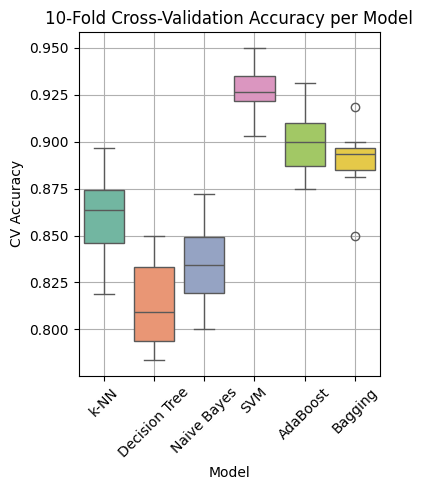

<ipython-input-6-bf4a71f2dfd1>:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test Accuracy", data=test_df, palette="Set3")


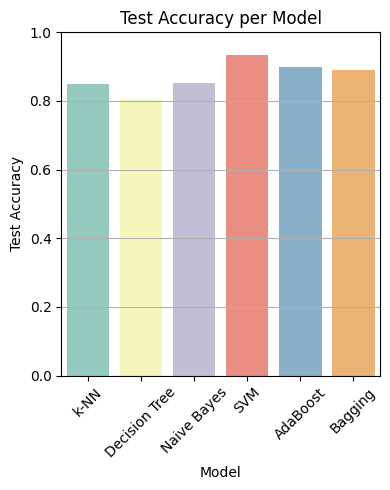

In [ ]:
# Define models
models = {
    "k-NN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": BernoulliNB(),
    "SVM": SVC(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42)
}

# Define parameter grids
param_grids = {
    "k-NN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "Decision Tree": {
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "Naive Bayes": {
        'alpha': [0.1, 1.0, 10.0]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    "Bagging": {
        'n_estimators': [50, 100, 150],
        'max_samples': [ 0.7],
        'max_features': [0.5]
    }
}

# Stratified K-Fold
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores_all = []
test_accuracies = []
final_results = []

print(" Performing Hyperparameter Tuning with Cross-Validation...\n")
for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=kfold, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    # 10-fold CV scores using best model
    fold_scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='accuracy')
    for score in fold_scores:
        cv_scores_all.append({'Model': name, 'CV Accuracy': score})

    # Test accuracy
    y_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    test_accuracies.append({'Model': name, 'Test Accuracy': test_accuracy})

    final_results.append({
        "Model": name,
        "Best Parameters": grid_search.best_params_,
        "CV Accuracy (Mean)": f"{np.mean(fold_scores):.4f}",
        "Test Accuracy": f"{test_accuracy:.4f}"
    })

# Convert to DataFrames
cv_df = pd.DataFrame(cv_scores_all)
test_df = pd.DataFrame(test_accuracies)
summary_df = pd.DataFrame(final_results)

# Print final summary
print("\n Final Results Summary:\n")
print(summary_df.to_string(index=False))

# === Plot 1: CV Accuracy Box Plot ===
plt.figure(figsize=(4, 5))
sns.boxplot(x="Model", y="CV Accuracy", data=cv_df, palette="Set2")
plt.title("10-Fold Cross-Validation Accuracy per Model")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot 2: Test Accuracy Bar Plot ===
plt.figure(figsize=(4, 5))
sns.barplot(x="Model", y="Test Accuracy", data=test_df, palette="Set3")
plt.title("Test Accuracy per Model")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
